## Kernel truncation

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from helper_functions import power_law_kernel, rayleigh_kernel, gaussian_kernel, sigmoid_kernel, exponential_kernel

In [19]:
T = 100
t_values = np.arange(T, 0, -1)

exp_params = [0.9, 0.5]

kernel_values_exp = exponential_kernel(exp_params, t_values, lag=1)

### Simulation with truncated kernel

In [20]:
from simulation import simulate_comb_sbm, simulate_mf_sbm
from synthetic_data import generate_sbm_adjacency_matrix

In [21]:
# Three community example

final_time = 100
num_nodes1 = 500
num_nodes2 = 5000
alphas =  np.array([0.5,0.3,0.2]) 
comm_size1 = (num_nodes1 * alphas).astype(int)
comm_size2 = (num_nodes2 * alphas).astype(int)

#Assertative
prob_matrix = np.array([[0.9, 0.2, 0.1],
                               [0.2, 0.9, 0.3],
                               [0.1, 0.3, 0.9]])

power_params =  [0.9, 2.5]
ray_params = [0.5, 1.0]
exp_params = [0.9, 0.5]

kernel_params_matrix = np.array([exp_params, ray_params, power_params])
kernel_params_matrix = np.array([exp_params, ray_params, power_params])
kernel_function_matrix = np.array([exponential_kernel, rayleigh_kernel, power_law_kernel])

In [22]:
power_params =  [0.9, 2.5]
ray_params = [0.5, 1.0]
exp_params = [0.9, 0.5]


# kernel_params_matrix = np.array([exp_params, ray_params, power_params])
# kernel_function_matrix = np.array([exponential_kernel, rayleigh_kernel, power_law_kernel])

kernel_params_matrix = np.array([exp_params, exp_params, exp_params])
kernel_function_matrix = np.array([exponential_kernel, exponential_kernel, exponential_kernel])


labs, adj_matrix = generate_sbm_adjacency_matrix(comm_size1, prob_matrix)
E = np.random.exponential(scale = 1.0, size = (final_time, num_nodes1, 100))
N_comb, lmbd_comb ,X_comb = simulate_comb_sbm(E, final_time,num_nodes1,comm_size1, kernel_function_matrix, kernel_params_matrix, adj_matrix, labs, mu_vector = np.array([0.9, 0.5, 0.3]), lag =1)

In [23]:
N_mf, lmbd_mf, X_mf, kernel_values = simulate_mf_sbm(E, final_time, comm_size1, prob_matrix, kernel_function_matrix, kernel_params_matrix,mu_vector = np.array([0.9, 0.5, 0.3]), lag =1)

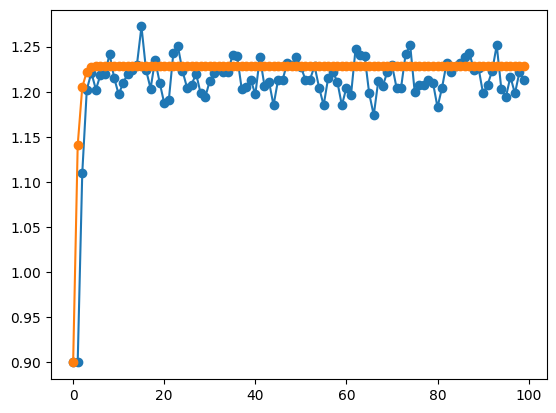

In [24]:
plt.plot(lmbd_comb[:,1], label='Community 1 - COMB', marker='o')
plt.plot(lmbd_mf[:,0], label='Community 1 - MF', marker = 'o')

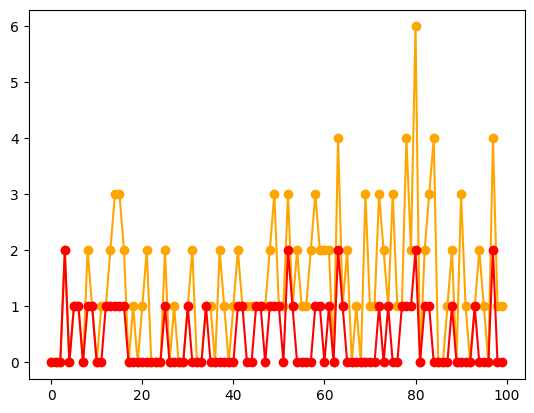

In [25]:
plt.plot(X_comb[:,5], label='Community 1 - COMB', marker='o', color = 'orange')
plt.plot(X_mf[:,5], label='Community 1 - MF', marker = 'o', color = 'red')

### Inference on the lagged data

In [26]:
from inference import jumps_per_community_over_time, lambda_bar_and_grad_for_all_times, loglik_approx, gradient_descent_fit, objective_and_grad, grad_loglik_fast, grad_loglik_intuitive

In [22]:
lag = 1
num_comm =len(alphas)

phi_community_one = np.array([
    [
        exponential_kernel(exp_params, t),
        exponential_kernel(exp_params, t),
        exponential_kernel(exp_params, t)
    ]
    for t in range(1, lag+1)
])

phi_true = np.repeat(phi_community_one[:, None, :], num_comm, axis=1)
mu_true = np.array([0.9, 0.5, 0.3])

mu0  = np.full(num_comm, 0.5)          # (num_comm,)
phi0 = np.random.uniform(
    0.0, 0.7,
    size=(lag, num_comm, num_comm)
)  

In [15]:
lambda_bar, grad_lambda_bar = lambda_bar_and_grad_for_all_times(
        mu_true, phi_true, alphas, prob_matrix, comm_size2, lag, final_time)

In [16]:
lambda_bar

array([[0.9       , 0.5       , 0.3       ],
       [1.14073202, 0.63264826, 0.37860637],
       [1.20506939, 0.66791447, 0.39941746],
       [1.2222558 , 0.6773059 , 0.40495093],
       [1.22684557, 0.67980947, 0.40642511],
       [1.22807111, 0.6804773 , 0.40681823],
       [1.22839832, 0.6806555 , 0.40692312],
       [1.22848568, 0.68070306, 0.40695111],
       [1.22850901, 0.68071576, 0.40695858],
       [1.22851523, 0.68071915, 0.40696057],
       [1.2285169 , 0.68072005, 0.40696111],
       [1.22851734, 0.68072029, 0.40696125],
       [1.22851746, 0.68072036, 0.40696129],
       [1.22851749, 0.68072038, 0.4069613 ],
       [1.2285175 , 0.68072038, 0.4069613 ],
       [1.2285175 , 0.68072038, 0.4069613 ],
       [1.2285175 , 0.68072038, 0.4069613 ],
       [1.2285175 , 0.68072038, 0.4069613 ],
       [1.2285175 , 0.68072038, 0.4069613 ],
       [1.2285175 , 0.68072038, 0.4069613 ],
       [1.2285175 , 0.68072038, 0.4069613 ],
       [1.2285175 , 0.68072038, 0.4069613 ],
       [1.

In [17]:
Y_comm = jumps_per_community_over_time(labs, X_comb)
A_bar = Y_comm.mean(axis=0) / comm_size1
print(A_bar)

[1.19228    0.67146667 0.3944    ]


### Gradiendt descent fit

In [ ]:
from inference import gradient_descent_fit_mu_only

In [ ]:
mu_hat, phi_hat, mu_iterates, phi_iterates, loglik_hist = gradient_descent_fit(
   mu_true, phi_true, alphas, prob_matrix, comm_size2,
    lag, X_comb, labs,
    lr_mu=1e-6, lr_phi=1e-6, max_iter=1000
)

NameError: name 'gradient_descent_fit' is not defined

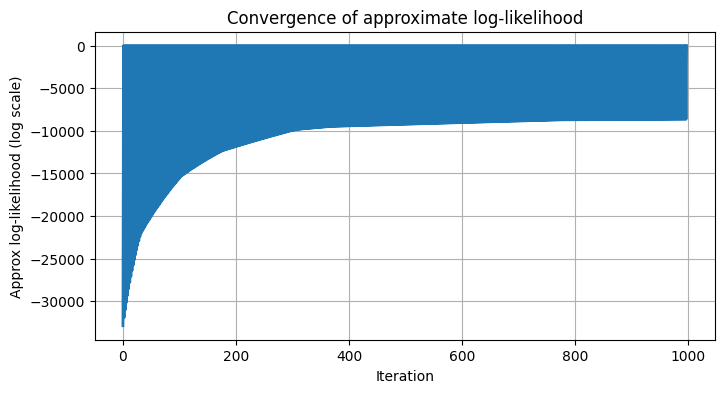

In [27]:
plt.figure(figsize=(8,4))
plt.plot(loglik_hist[2:], lw=2)
#plt.yscale("log")   
plt.xlabel("Iteration")
plt.ylabel("Approx log-likelihood (log scale)")
plt.title("Convergence of approximate log-likelihood")
plt.grid(True)
plt.show()

In [ ]:
colors = ['r', 'g', 'b']

plt.figure(figsize=(8,4))

for h in range(num_comm):
    plt.plot(mu_iterates[:, h], label=f"μ_{h} estimate", color=colors[h])

# plot true value as horizontal lines
for h in range(num_comm):
    plt.axhline(mu_true[h], color=colors[h], linestyle='--', linewidth=1)

plt.xlabel("Iteration")
plt.ylabel("μ values")
plt.title("Estimated μ values over iterations")
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'mu_iterates' is not defined

<Figure size 800x400 with 0 Axes>

In [13]:
h = 0
plt.figure(figsize=(10,6))

# get a colormap with enough distinct colors
cmap = plt.cm.get_cmap("tab20", num_comm * 2)

color_index = 0

for r in range(num_comm):
    for m in range(1):
        color = cmap(color_index)
        color_index += 1

        # estimated trajectory
        plt.plot(
            phi_iterates[:, m, h, r],
            label=f"φ[{h}->{r}][{m}]",
            color=color
        )

        # true value (same color, dashed)
        plt.axhline(
            phi_true[m, h, r],
            linestyle="--",
            linewidth=1,
            color=color
        )
        print(phi_true[m, h, r])

plt.xlabel("Iteration")
plt.ylabel("φ values")
plt.title(f"φ parameters for community h = {h}")
plt.legend(ncol=4, fontsize=7)
plt.grid(True)
plt.show()


NameError: name 'num_comm' is not defined

<Figure size 1000x600 with 0 Axes>

In [31]:
mu_hat

array([0.25      , 0.15      , 0.10112331])

In [32]:
phi_hat

array([[[1.11412854e-11, 1.01515000e-11, 2.22438460e-01],
        [1.01521702e-11, 1.04090500e-11, 1.00909000e-11],
        [1.00512855e-11, 1.00919071e-11, 1.01838142e-11]]])

### LBFGS fit

In [76]:
# Combine parameters
params0 = np.concatenate([mu0.flatten(), phi0.flatten()])
n_mu = len(mu0.flatten())

def objective_for_optimizer(params):
    mu = params[:n_mu].reshape(mu0.shape)
    phi = params[n_mu:].reshape(phi0.shape)
    
    loglik, grad = objective_and_grad(mu, phi, alphas, prob_matrix, 
                                      comm_size2, lag, X_comb, labs)
    
    # L-BFGS minimizes, so return negative log-likelihood
    nll = -loglik
    grad_combined = -np.concatenate([grad[0].flatten(), grad[1].flatten()])
    
    return nll


In [77]:
# Run L-BFGS
result = minimize(objective_for_optimizer, params0, method='L-BFGS-B', jac=False,
                  options={'maxiter': 1000})

# Extract results
mu_hat_optimizer = result.x[:n_mu].reshape(mu0.shape)
phi_hat_optimizer = result.x[n_mu:].reshape(phi0.shape)

In [ ]:
print(mu_hat_optimizer)
print(phi_hat_optimizer)

[-5.50027209 -7.57618581 -5.84800812]
[[[  21.25511313 -116.30471449  -55.81073105]
  [ 113.68977231  -26.18767712  -49.19726564]
  [ 174.2576388   -66.74625678   -8.21897127]]]


In [ ]:
colors = ['r', 'g', 'b']

plt.figure(figsize=(8,4))

for h in range(num_comm):
    plt.plot(mu_iterates[:, h], label=f"μ_{h} estimate", color=colors[h])

# plot true value as horizontal lines
for h in range(num_comm):
    plt.axhline(mu_true[h], color=colors[h], linestyle='--', linewidth=1)

plt.xlabel("Iteration")
plt.ylabel("μ values")
plt.title("Estimated μ values over iterations")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'plt' is not defined

# Approach 2

In [6]:
from inference import compute_d, compute_k, compute_Jh_aggregated, build_M, compute_nu_given_inputs, compute_J_ultra_optimized, compute_nu_given_inputes_vectorized

In [7]:
final_time = 100
num_nodes1 = 500
num_nodes2 = 5000
alphas =  np.array([0.5,0.3,0.2]) 
comm_size1 = (num_nodes1 * alphas).astype(int)
comm_size2 = (num_nodes2 * alphas).astype(int)


#Assertative
prob_matrix = np.array([[0.9, 0.2, 0.1],
                               [0.2, 0.9, 0.3],
                               [0.1, 0.3, 0.9]])

In [8]:
power_params =  [0.9, 2.5]
ray_params = [0.5, 1.0]
exp_params = [0.9, 0.5]


kernel_params_matrix = np.array([exp_params, ray_params, power_params])
kernel_params_matrix = np.array([exp_params, ray_params, power_params])
kernel_function_matrix = np.array([exponential_kernel, rayleigh_kernel, power_law_kernel])


labs, adj_matrix = generate_sbm_adjacency_matrix(comm_size1, prob_matrix)
E = np.random.exponential(scale = 1.0, size = (final_time, num_nodes1, 100))
N_comb, lmbd_comb ,X_comb = simulate_comb_sbm(E, final_time,num_nodes1,comm_size1, kernel_function_matrix, kernel_params_matrix, adj_matrix, labs, mu_vector = np.array([0.9, 0.5, 0.3]),lag =1)
N_mf, lmbd_mf, X_mf, kernel_values = simulate_mf_sbm(E, final_time, comm_size1, prob_matrix, kernel_function_matrix, kernel_params_matrix)

In [9]:
p = 1

d = compute_d(X_comb, adj_matrix, p)
print("d computed")
k = compute_k(X_comb, adj_matrix, p)
print("k computed")
J = compute_J_ultra_optimized(X_comb, adj_matrix, p)
print("J list computed")
M = build_M(comm_size1, p)
print("M computed")

print("Starting mu computation")
mus = compute_nu_given_inputs(d, k, J, M, labs, X_comb, comm_size1)

d computed
k computed
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271


In [12]:
mus

[array([-8.49267130e-01, -1.04188882e-03, -2.63296864e-03, -1.91081841e-05]),
 array([-7.96973742e-01, -3.02356682e-04, -7.29459355e-04,  2.74059976e-04]),
 array([-5.77992010e-01, -1.16941307e-04, -4.19873672e-04, -3.10785745e-04])]

In [11]:
mus[0][0]

np.float64(-0.849267129732084)